# YZM0206 Proje - InceptionV3 Transfer Learning ve Fine-tuning

Bu notebookta EuroSAT RGB veri seti üzerinde InceptionV3 modeli kullanılarak transfer learning ve fine-tuning uygulanmıştır. Bu model, MobileNetV2 ve DenseNet121 sonuçlarından sonra üçüncü hazır ağırlıklı model olarak projeye eklenmiştir.

InceptionV3, aynı görüntü üzerinde farklı ölçeklerde özellik çıkarabilen inception bloklarıyla bilinir. Bu yapı, küçük uydu görüntülerinde hem geniş alan örüntülerini hem de daha lokal doku ayrıntılarını yakalamak için anlamlı bir karşılaştırma sağlar.

Bu notebookun projedeki yeri:

1. İlk notebookta veri seti incelenmiş ve sabit train / validation / test ayrımı oluşturulmuştur.
2. İkinci notebookta hazır ağırlık kullanmadan baseline CNN modeli eğitilmiştir.
3. Üçüncü notebookta MobileNetV2 ile hafif bir transfer learning modeli denenmiştir.
4. Dördüncü notebookta DenseNet121 ile daha güçlü bir transfer learning modeli denenmiştir.
5. Bu notebookta InceptionV3 ile farklı mimari yapıya sahip bir transfer learning deneyi yapılmıştır.

Bu çalışma iki aşamadan oluşur:

1. Feature extraction: InceptionV3 tabanı dondurulur ve sadece yeni sınıflandırma katmanları eğitilir.
2. Fine-tuning: InceptionV3 tabanının son katmanlarından bir kısmı düşük learning rate ile tekrar eğitilir.

Amaç, farklı bir hazır model mimarisinin EuroSAT sınıflandırmasında nasıl davrandığını görmek ve sonuçları diğer modellerle karşılaştırmaktır.

## Kütüphaneler ve proje dizinleri

Bu bölümde model eğitimi, değerlendirme ve görselleştirme için gerekli kütüphaneler içe aktarılmıştır. Rastgelelik kontrolü için seed değeri sabitlenmiştir. Böylece veri okuma sırası ve eğitim başlangıcı mümkün olduğunca tekrar üretilebilir hale getirilmiştir.

Ayrıca proje içindeki data, figures, models ve reports klasörleri tanımlanmıştır. Eğitim çıktıları bu klasörlere kaydedileceği için sonraki karşılaştırma notebookunda aynı dosyalar tekrar kullanılabilecektir.

In [2]:
import json
import random
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")

try:
    import importlib
    importlib.import_module("google.colab.drive").mount("/content/drive")
except Exception:
    pass


def find_project_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for root in [Path("/content") / "drive" / "MyDrive", Path("/content") / "drive" / "Shareddrives"]:
        project_candidate = root / "YZM0206 Proje"
        if project_candidate.exists():
            candidates.append(project_candidate)

    for candidate in candidates:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Proje klasörü bulunamadı. Notebook proje klasörü içinden çalıştırılmalıdır.")


def count_images(directory):
    if not directory.exists():
        return 0
    return sum(1 for _ in directory.glob("*/*.jpg"))


def split_zip_counts(zip_path):
    counts = {"train": 0, "valid": 0, "test": 0}

    if not zip_path.exists():
        return counts

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        for name in zip_ref.namelist():
            parts = name.split("/")
            if len(parts) == 3 and parts[0] in counts and name.lower().endswith(".jpg"):
                counts[parts[0]] += 1

    return counts


def prepare_local_split_from_zip():
    if not SPLIT_ZIP_PATH.exists():
        raise FileNotFoundError("Split zip dosyası bulunamadı. Önce 01_dataset_preparation.ipynb çalıştırılmalıdır.")

    expected = split_zip_counts(SPLIT_ZIP_PATH)

    if sum(expected.values()) != 27000:
        raise RuntimeError("Split zip dosyası beklenen 27000 görüntüyü içermiyor.")

    split_ready = all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items())

    if split_ready:
        return

    if SPLIT_ROOT.exists():
        shutil.rmtree(SPLIT_ROOT)

    SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(SPLIT_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(SPLIT_ROOT)

    if not all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items()):
        raise RuntimeError("Split zip dosyası çalışma alanına eksik çıkarıldı.")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_ZIP_PATH = PROCESSED_DIR / "eurosat_split_seed42.zip"

LOCAL_WORK_DIR = Path("/content/eurosat_work") if Path("/content").exists() else DATA_DIR / "local_work"
SPLIT_ROOT = LOCAL_WORK_DIR / "split_seed42"
SPLIT_DIRS = {
    "train": SPLIT_ROOT / "train",
    "valid": SPLIT_ROOT / "valid",
    "test": SPLIT_ROOT / "test",
}
TRAIN_DIR = SPLIT_DIRS["train"]
VALID_DIR = SPLIT_DIRS["valid"]
TEST_DIR = SPLIT_DIRS["test"]

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

prepare_local_split_from_zip()

print("Hazırlık tamamlandı.")
print("TensorFlow:", tf.__version__)
print("Train görüntü sayısı:", count_images(TRAIN_DIR))
print("Validation görüntü sayısı:", count_images(VALID_DIR))
print("Test görüntü sayısı:", count_images(TEST_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Hazırlık tamamlandı.
TensorFlow: 2.20.0
Train görüntü sayısı: 18900
Validation görüntü sayısı: 4050
Test görüntü sayısı: 4050


## Veri kümelerini yükleme

Bu bölümde ilk notebookta oluşturulan sabit train / validation / test ayrımı yüklenmiştir. Aynı split dosyasının kullanılması model karşılaştırmasının adil olması için gereklidir. Böylece baseline CNN, MobileNetV2, DenseNet121 ve InceptionV3 aynı eğitim, doğrulama ve test görüntüleriyle değerlendirilir.

Görüntüler 224x224 boyutunda okunmuştur. InceptionV3 orijinal uygulamalarda çoğunlukla 299x299 giriş boyutuyla kullanılsa da burada 224x224 tercih edilmiştir. Bunun nedeni, projedeki tüm modelleri aynı görüntü boyutunda karşılaştırmak ve eğitim maliyetini daha kontrollü tutmaktır. Keras uygulamasında include_top=False kullanıldığı için InceptionV3 bu giriş boyutuyla çalışabilir.

Batch size 16 seçilmiştir. InceptionV3, baseline CNN'e göre daha büyük bir modeldir. Bu nedenle aynı anda işlenen görüntü sayısını 16 tutmak bellek kullanımını azaltır. Batch size modelin veri içeriğini değiştirmez; yalnızca eğitim sırasında kaç görüntünün birlikte işleneceğini belirler.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)

dataset_sizes = {
    "train": count_images(TRAIN_DIR),
    "valid": count_images(VALID_DIR),
    "test": count_images(TEST_DIR),
}

print("Sınıf sayısı:", num_classes)
print("Sınıflar:", class_names)
print("Veri bölünmesi:", dataset_sizes)

Found 18900 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Sınıf sayısı: 10
Sınıflar: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Veri bölünmesi: {'train': 18900, 'valid': 4050, 'test': 4050}


## Veri pipeline hazırlığı

Bu adımda prefetch kullanılmıştır. Prefetch, model bir batch üzerinde eğitim yaparken bir sonraki batchin arka planda hazırlanmasını sağlar. Bu işlem modelin sonucunu değiştirmez; sadece veri okuma ve eğitim akışını daha verimli hale getirir.

Bu bölümde ayrıca manuel 0-1 normalizasyon yapılmamıştır. Çünkü InceptionV3, ImageNet üzerinde kendi preprocessing düzeniyle eğitilmiştir. Bu nedenle görüntüler model mimarisi içinde InceptionV3 preprocessing fonksiyonundan geçirilecektir.

In [4]:
train_data = train_data.prefetch(AUTOTUNE)
valid_data = valid_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

print("Veri pipeline hazır.")

Veri pipeline hazır.


## InceptionV3 preprocessing ve augmentation

InceptionV3 modeli ImageNet üzerinde belirli bir giriş ölçeğiyle eğitilmiştir. Bu nedenle görüntüler modele verilmeden önce InceptionV3 için tanımlı preprocess input fonksiyonundan geçirilmiştir. Bu fonksiyon piksel değerlerini modelin beklediği aralığa dönüştürür.

Bu notebookta kullanılan augmentation işlemleri kontrollü geometrik dönüşümlerdir:

1. RandomFlip: görüntüyü yatay ve dikey yönde çevirebilir.
2. RandomRotation(0.15): görüntüyü sınırlı bir açı aralığında döndürebilir.
3. RandomZoom(0.15): görüntüye küçük yakınlaştırma veya uzaklaştırma etkisi uygular.
4. RandomTranslation(0.10, 0.10): görüntüyü yatay ve dikey eksende sınırlı oranda kaydırır.

Bu işlemler yalnızca eğitim sırasında uygulanır. Validation ve test görüntülerine augmentation uygulanmaz. Böylece model daha çeşitli örnekler görür, fakat değerlendirme gerçek veri dağılımı üzerinde yapılır.

Brightness ve contrast gibi renk tabanlı işlemler bu ana deneye eklenmemiştir. EuroSAT RGB görüntülerinde renk, bitki örtüsü ve yüzey dokusu sınıf ayrımı için önemli olabileceğinden, renk bilgisini bozabilecek işlemlerden kaçınılmıştır.

In [5]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
], name="data_augmentation")

print("InceptionV3 preprocessing ve augmentation katmanları hazır.")

InceptionV3 preprocessing ve augmentation katmanları hazır.


## InceptionV3 model mimarisi

Bu bölümde ImageNet üzerinde önceden eğitilmiş InceptionV3 tabanı alınmıştır. include_top parametresi False seçilmiştir; çünkü ImageNet'in orijinal 1000 sınıflı çıkış katmanı EuroSAT için uygun değildir. EuroSAT veri setinde 10 sınıf olduğu için modelin sonuna yeni bir sınıflandırıcı başlık eklenmiştir.

InceptionV3'ün temel fikri, görüntüden farklı ölçeklerde özellik çıkarabilmektir. Bir arazi görüntüsünde bazı sınıflar geniş alan dokularıyla, bazıları ise daha küçük yapısal ayrıntılarla ayırt edilir. Bu yüzden InceptionV3, MobileNetV2 ve DenseNet121'den farklı bir mimari bakış açısı sağlar.

Mimarideki temel parçalar:

1. InceptionV3 convolutional tabanı hazır görsel özellikleri çıkarır.
2. GlobalAveragePooling2D katmanı özellik haritalarını kompakt bir vektöre indirir.
3. Dropout(0.30) katmanı overfitting riskini azaltmaya yardımcı olur.
4. Dense softmax katmanı 10 EuroSAT sınıfı için olasılık üretir.

Dropout oranı 0.30 seçilmiştir. Bu değer, son sınıflandırıcı katmanda makul düzeyde regularization sağlar. Çok düşük dropout overfitting'i azaltmada yetersiz kalabilir, çok yüksek dropout ise öğrenmeyi gereğinden fazla zorlaştırabilir.

In [6]:
base_model = InceptionV3(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=IMG_SIZE + (3,), name="input_layer")
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.30, name="dropout")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

model = tf.keras.Model(inputs, outputs, name="inceptionv3_transfer_learning")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

feature_trainable_params = int(sum(np.prod(weight.shape) for weight in model.trainable_weights))
print("Feature extraction aşamasındaki eğitilebilir parametre sayısı:", feature_trainable_params)

Model: "inceptionv3_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,823,274 (83.25 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Feature extraction aşamasındaki eğitilebilir parametre sayısı: 20490


## Feature extraction eğitimi

Feature extraction aşamasında InceptionV3 tabanı dondurulmuştur. Bu nedenle model ImageNet'ten öğrendiği genel görsel özellikleri kullanır, fakat bu özelliklerin EuroSAT sınıflarına nasıl bağlanacağını yeni eklenen son katmanlar öğrenir.

Bu aşamada learning rate 1e-3 seçilmiştir. Çünkü yalnızca yeni eklenen sınıflandırıcı katmanlar eğitilmektedir ve hazır convolutional tabanın ağırlıkları değişmemektedir. Bu nedenle fine-tuning aşamasına göre daha yüksek learning rate kullanılabilir.

Feature extraction için 15 epoch üst sınır olarak verilmiştir. Ancak EarlyStopping kullanıldığı için model validation accuracy uzun süre iyileşmezse eğitim daha erken durabilir. Böylece gereksiz epoch çalıştırmak ve overfitting riskini artırmak engellenir.

Eğitimde üç callback kullanılmıştır:

1. ModelCheckpoint en iyi validation accuracy değerini veren modeli kaydeder.
2. ReduceLROnPlateau validation loss iyileşmediğinde learning rate değerini azaltır.
3. EarlyStopping validation accuracy uzun süre iyileşmezse eğitimi durdurur ve en iyi ağırlıkları geri yükler.

In [7]:
FEATURE_EPOCHS = 15

feature_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "inceptionv3_feature_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history_feature = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=FEATURE_EPOCHS,
    callbacks=feature_callbacks
)

feature_training_time = time.time() - start_time
print("Feature extraction eğitim süresi (sn):", round(feature_training_time, 2))

Epoch 1/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7149 - loss: 0.8750
Epoch 1: val_accuracy improved from None to 0.87580, saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_feature_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_feature_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 96s 71ms/step - accuracy: 0.8064 - loss: 0.5908 - val_accuracy: 0.8758 - val_loss: 0.3818 - learning_rate: 0.0010
Epoch 2/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8618 - loss: 0.4242
Epoch 2: val_accuracy improved from 0.87580 to 0.88963, saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_feature_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_feature_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - accuracy: 0.8646 - loss: 0.4161 - val_accuracy: 0.8896 - val_loss: 0.3384 - learning_rate: 0.0010
Epoch 3/15
1181/1182 

In [8]:
feature_history_df = pd.DataFrame(history_feature.history)
feature_history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.806402,0.590824,0.875802,0.381769,0.00100
1,0.864550,0.416074,0.889630,0.338437,0.00100
2,0.869524,0.408484,0.891111,0.339610,0.00100
3,0.875079,0.395767,0.904938,0.295474,0.00100
4,0.874709,0.403655,0.905185,0.302589,0.00100
5,0.872698,0.404005,0.908395,0.292340,0.00100
6,0.878307,0.382716,0.900000,0.323166,0.00100
7,0.874709,0.409487,0.904198,0.313874,0.00100
8,0.881746,0.379932,0.915309,0.264088,0.00050
9,0.889365,0.354881,0.915556,0.261585,0.00050


## Feature extraction ara değerlendirmesi

Bu değerlendirme test kümesi üzerinde değil, validation kümesi üzerinde yapılmıştır. Amaç fine-tuning öncesinde modelin durumunu görmek ve sonraki aşamada gerçekten bir iyileşme olup olmadığını karşılaştırabilmektir.

InceptionV3 feature extraction sonunda validation loss 0.2443, validation accuracy ise 0.9207 olarak ölçülmüştür. Bu değer baseline CNN'den belirgin şekilde yüksektir; ancak MobileNetV2 ve DenseNet121 feature extraction sonuçlarının biraz gerisindedir.

Test kümesi final performans için saklanır. Böylece model seçiminde doğrudan test sonucuna göre karar verilmemiş olur.

In [9]:
feature_val_loss, feature_val_accuracy = model.evaluate(valid_data)

print("Feature extraction validation loss değeri:", feature_val_loss)
print("Feature extraction validation accuracy değeri:", feature_val_accuracy)

254/254 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9207 - loss: 0.2443
Feature extraction validation loss değeri: 0.24431253969669342
Feature extraction validation accuracy değeri: 0.9207407236099243


## Feature extraction yorumu

Feature extraction aşamasında model 15 epoch çalışmıştır. İlk epochta validation accuracy 0.8758 iken eğitim sonunda 0.9207 seviyesine ulaşılmıştır. Bu sonuç, InceptionV3 tabanı donduruluyken bile ImageNet ağırlıklarının EuroSAT için faydalı olduğunu göstermektedir.

Bununla birlikte feature extraction aşamasında InceptionV3, MobileNetV2'nin 0.9314 ve DenseNet121'in 0.9427 validation accuracy değerlerinin gerisinde kalmıştır. Bu nedenle InceptionV3 için fine-tuning aşamasının daha kritik olduğu söylenebilir.

## Fine-tuning hazırlığı

Fine-tuning aşamasında InceptionV3 tabanının son katmanlarından bir kısmı tekrar eğitime açılmıştır. Erken katmanlar genellikle kenar, renk geçişi ve temel doku gibi genel özellikleri öğrenir. Son katmanlar ise daha karmaşık ve veri setine yakın özellikleri temsil eder. Bu yüzden sadece son bölümün açılması daha kontrollü bir yaklaşımdır.

Bu notebookta InceptionV3 tabanının son 60 katmanı eğitime açılmıştır. InceptionV3 katman sayısı fazla olduğu için 60 katman, modelin son bölümünü uyarlamak için makul bir aralık sağlar. Tüm modeli açmak daha fazla hesaplama gerektirir ve hazır ağırlıkların bozulma riskini artırabilir.

BatchNormalization katmanları dondurulmuştur. Bu katmanların eğitim sırasında istatistiklerini değiştirmesi küçük veya farklı dağılımlı veri setlerinde kararsız sonuçlara yol açabilir. Bu nedenle fine-tuning sırasında BatchNormalization katmanlarını sabit tutmak daha güvenli bir tercihtir.

Fine-tuning için learning rate 1e-5 seçilmiştir. Bu değer feature extraction aşamasındaki 1e-3 değerinden çok daha küçüktür. Amaç, hazır ağırlıkları tamamen değiştirmek değil, son katmanları EuroSAT veri setine kontrollü şekilde uyarlamaktır.

In [10]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 60

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNormalization katmanlarını dondurmak fine-tuning sürecini daha stabil hale getirir.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
trainable_layer_names = [layer.name for layer in base_model.layers if layer.trainable]

print("InceptionV3 toplam katman sayısı:", len(base_model.layers))
print("Fine-tuning için eğitilebilir katman sayısı:", trainable_layers)
print("Eğitilebilir son katmanlardan örnekler:", trainable_layer_names[:5])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

InceptionV3 toplam katman sayısı: 311
Fine-tuning için eğitilebilir katman sayısı: 43
Eğitilebilir son katmanlardan örnekler: ['activation_80', 'conv2d_77', 'conv2d_81', 'activation_77', 'activation_81']


## Fine-tuning eğitimi

Bu aşamada model tekrar eğitilmiştir. Artık yalnızca son sınıflandırıcı katmanlar değil, InceptionV3 tabanının son bölümündeki bazı katmanlar da güncellenmektedir.

Fine-tuning için 10 epoch üst sınır olarak belirlenmiştir. Bu aşamada learning rate düşük olduğu için model küçük güncellemeler yapar. Yine de validation performansı iyileşmezse EarlyStopping eğitimi erken durdurabilir.

Beklenen sonuç, feature extraction aşamasındaki performansın üzerine kontrollü bir iyileşme gelmesidir. Ancak fine-tuning her zaman accuracy değerini artırmak zorunda değildir. Eğer validation loss yükselirse veya validation accuracy düşerse, model veri setine fazla uyum sağlamaya başlamış olabilir.

In [11]:
FINE_TUNE_EPOCHS = 10

fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "inceptionv3_finetuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

fine_tuning_time = time.time() - start_time
print("Fine-tuning eğitim süresi (sn):", round(fine_tuning_time, 2))

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8933 - loss: 0.3159
Epoch 1: val_accuracy improved from None to 0.93086, saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_finetuned_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 113s 87ms/step - accuracy: 0.9047 - loss: 0.2840 - val_accuracy: 0.9309 - val_loss: 0.2045 - learning_rate: 1.0000e-05
Epoch 2/10
1181/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9184 - loss: 0.2348
Epoch 2: val_accuracy improved from 0.93086 to 0.94025, saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/inceptionv3_finetuned_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 100s 85ms/step - accuracy: 0.9256 - loss: 0.2204 - val_accuracy: 0.9402 - val_loss: 0.1744 - learning_rate: 1.0000e-05
Epo

In [12]:
fine_history_df = pd.DataFrame(history_fine.history)
fine_history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.904709,0.283982,0.930864,0.204508,0.00001
1,0.925608,0.220370,0.940247,0.174409,0.00001
2,0.933862,0.191254,0.941235,0.163874,0.00001
3,0.938201,0.177012,0.946173,0.155593,0.00001
4,0.945661,0.158976,0.947407,0.151997,0.00001
5,0.946825,0.152913,0.947901,0.159274,0.00001
6,0.950265,0.144100,0.952099,0.138637,0.00001
7,0.953492,0.132617,0.952593,0.139673,0.00001
8,0.954762,0.128943,0.956543,0.131217,0.00001
9,0.957143,0.122849,0.955309,0.129253,0.00001


## Eğitim grafiklerinin hazırlanması

Feature extraction ve fine-tuning iki ayrı eğitim aşaması olduğu için bu bölümde iki history nesnesi birleştirilmiştir. Grafikte dikey çizgi fine-tuning başlangıcını gösterir.

Bu grafikler modelin öğrenme davranışını yorumlamak için kullanılacaktır. Özellikle train accuracy ile validation accuracy arasındaki fark, overfitting ihtimalini değerlendirmek açısından önemlidir.

In [13]:
def combine_histories(history_a, history_b):
    combined = {}
    keys = sorted(set(history_a.history.keys()) | set(history_b.history.keys()))

    for key in keys:
        combined[key] = history_a.history.get(key, []) + history_b.history.get(key, [])

    history_df = pd.DataFrame(combined)
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))
    history_df.insert(
        1,
        "phase",
        ["feature_extraction"] * len(history_a.history["loss"]) + ["fine_tuning"] * len(history_b.history["loss"])
    )
    return history_df


history_df = combine_histories(history_feature, history_fine)
history_df

,epoch,phase,accuracy,learning_rate,loss,val_accuracy,val_loss
0,1,feature_extraction,0.806402,0.00100,0.590824,0.875802,0.381769
1,2,feature_extraction,0.864550,0.00100,0.416074,0.889630,0.338437
2,3,feature_extraction,0.869524,0.00100,0.408484,0.891111,0.339610
3,4,feature_extraction,0.875079,0.00100,0.395767,0.904938,0.295474
4,5,feature_extraction,0.874709,0.00100,0.403655,0.905185,0.302589
5,6,feature_extraction,0.872698,0.00100,0.404005,0.908395,0.292340
6,7,feature_extraction,0.878307,0.00100,0.382716,0.900000,0.323166
7,8,feature_extraction,0.874709,0.00100,0.409487,0.904198,0.313874
8,9,feature_extraction,0.881746,0.00050,0.379932,0.915309,0.264088
9,10,feature_extraction,0.889365,0.00050,0.354881,0.915556,0.261585


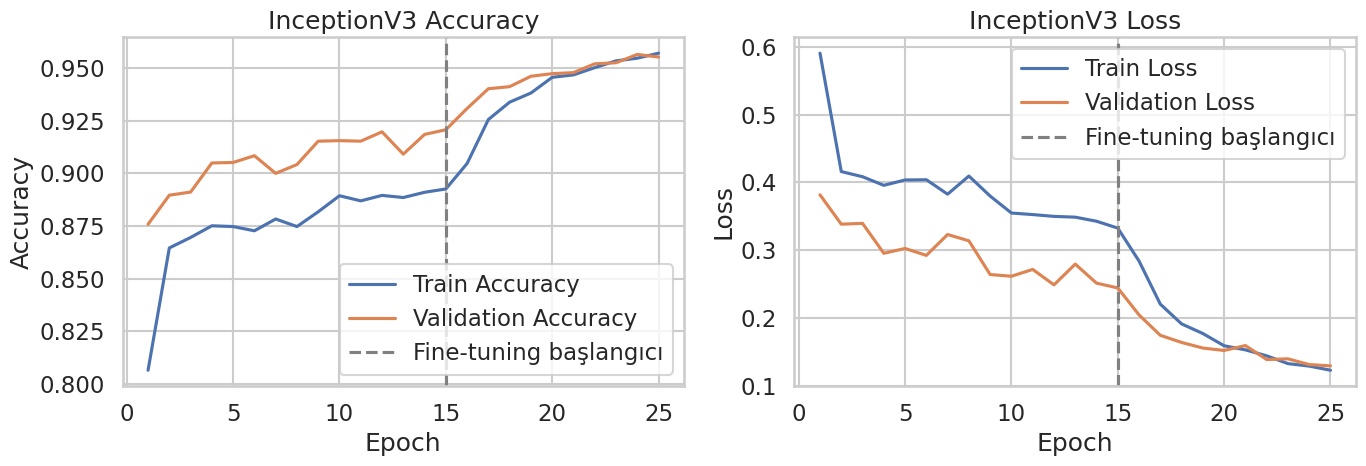

In [14]:
feature_epoch_count = len(history_feature.history["loss"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
plt.axvline(feature_epoch_count, color="gray", linestyle="--", label="Fine-tuning başlangıcı")
plt.title("InceptionV3 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.axvline(feature_epoch_count, color="gray", linestyle="--", label="Fine-tuning başlangıcı")
plt.title("InceptionV3 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "inceptionv3_accuracy_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Eğitim eğrilerinin yorumu

Feature extraction aşamasında en iyi validation accuracy 0.9207 olarak elde edilmiştir. Fine-tuning sonrasında en iyi validation accuracy 0.9565 seviyesine yükselmiştir. Bu yaklaşık 3.6 yüzde puanlık artış, InceptionV3 için fine-tuning adımının oldukça etkili olduğunu göstermektedir.

Son epochta train accuracy 0.9571, validation accuracy ise 0.9553 değerindedir. Train ve validation değerlerinin birbirine çok yakın olması, fine-tuning sonrasında güçlü bir overfitting belirtisi olmadığını düşündürmektedir.

Validation loss değerinin 0.1293 seviyesine kadar düşmesi, modelin fine-tuning sonrasında daha dengeli ve güvenli tahminler ürettiğini göstermektedir.

## Test kümesi değerlendirmesi

Test kümesi eğitim sırasında kullanılmamıştır. Bu nedenle final performans değerlendirmesi bu bölümde yapılmıştır. Validation kümesi modelin eğitim sürecini takip etmek için kullanılırken, test kümesi modelin daha tarafsız başarısını ölçmek için ayrılmıştır.

InceptionV3 modeli test kümesinde 0.9610 accuracy ve 0.1260 loss değerine ulaşmıştır. Bu sonuç baseline CNN modelinin 0.8207 test accuracy değerinin yaklaşık 14.0 yüzde puan üzerindedir.

In [15]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test loss değeri:", test_loss)
print("Test accuracy değeri:", test_accuracy)

254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9610 - loss: 0.1260
Test loss değeri: 0.12597931921482086
Test accuracy değeri: 0.9609876275062561


## Tahminlerin alınması

Classification report ve confusion matrix hesaplamak için test kümesindeki gerçek etiketler ile model tahminleri ayrı listelerde toplanmıştır. Model her görüntü için 10 sınıfa ait olasılık üretir. En yüksek olasılığa sahip sınıf tahmin edilen sınıf olarak alınmıştır.

In [16]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Tahmin sayısı:", len(y_pred))

Tahmin sayısı: 4050


## Classification report

Accuracy tek başına yeterli değildir. Model genel olarak başarılı görünse bile bazı sınıflarda düşük performans gösterebilir. Bu nedenle precision, recall ve F1-score değerleri hesaplanmıştır.

Precision, modelin bir sınıf için yaptığı pozitif tahminlerin ne kadarının doğru olduğunu gösterir. Recall, o sınıfa ait gerçek örneklerin ne kadarının yakalandığını gösterir. F1-score ise precision ve recall değerlerini birlikte değerlendirir.

Macro ortalama her sınıfa eşit ağırlık verir. Weighted ortalama ise sınıf örnek sayılarını dikkate alır. EuroSAT tamamen eşit sınıflı olmadığı için iki ortalamanın birlikte verilmesi daha sağlıklı bir değerlendirme sağlar.

In [17]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(REPORTS_DIR / "inceptionv3_classification_report.csv", encoding="utf-8-sig")
report_df

,precision,recall,f1-score,support
AnnualCrop,0.939130,0.960000,0.949451,450.000000
Forest,0.978022,0.988889,0.983425,450.000000
HerbaceousVegetation,0.944568,0.946667,0.945616,450.000000
Highway,0.956989,0.949333,0.953146,375.000000
Industrial,0.983827,0.973333,0.978552,375.000000
Pasture,0.926421,0.923333,0.924875,300.000000
PermanentCrop,0.929688,0.952000,0.940711,375.000000
Residential,0.982183,0.980000,0.981090,450.000000
River,0.964187,0.933333,0.948509,375.000000
SeaLake,0.993274,0.984444,0.988839,450.000000


## Sınıf bazlı performans yorumu

Classification report incelendiğinde InceptionV3 modelinin yüksek ve dengeli bir performans verdiği görülmektedir. En yüksek F1-score değerleri SeaLake (0.9888), Forest (0.9834), Residential (0.9811) ve Industrial (0.9786) sınıflarında elde edilmiştir.

En düşük F1-score değerleri Pasture (0.9249), PermanentCrop (0.9407) ve HerbaceousVegetation (0.9456) sınıflarındadır. Bu sınıflar tarım ve bitki örtüsü gruplarına yakın olduğu için görsel olarak daha zor ayrılabilir. Buna rağmen en düşük F1-score değerinin 0.9249 olması, InceptionV3 modelinin genel olarak güçlü bir sınıf ayrımı yaptığını göstermektedir.

Macro F1-score değeri 0.9594, weighted F1-score değeri ise 0.9610 olarak hesaplanmıştır. Bu değerler genel accuracy sonucunun sınıf bazlı metriklerle de desteklendiğini göstermektedir.

## Confusion matrix

Confusion matrix, modelin hangi sınıfları hangi sınıflarla karıştırdığını gösterir. Satırlar gerçek sınıfları, sütunlar tahmin edilen sınıfları temsil eder.

Bu analiz özellikle hata yorumları için önemlidir. Örneğin model PermanentCrop görüntülerini AnnualCrop olarak tahmin ediyorsa, bu iki sınıfın görsel benzerliği raporda tartışılabilir.

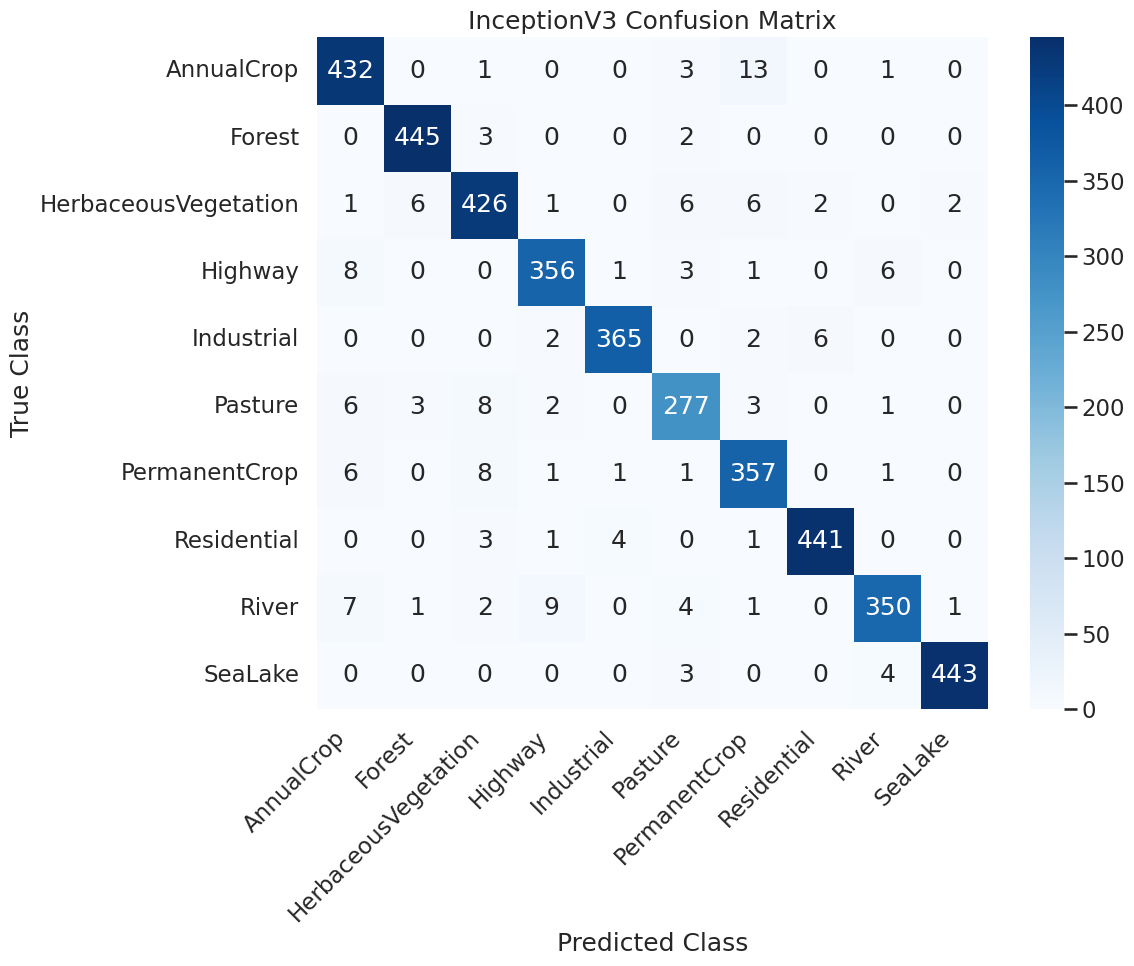

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("InceptionV3 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "inceptionv3_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion matrix yorumu

Confusion matrix çıktısı, InceptionV3 modelinde hataların büyük ölçüde azaldığını göstermektedir. SeaLake, Forest, Residential ve Industrial sınıfları en güçlü ayrılan sınıflar arasındadır.

Pasture, PermanentCrop ve HerbaceousVegetation sınıfları görece daha düşük F1-score değerlerine sahiptir. Bu durum bitki örtüsü ve tarımsal alan sınıflarının görsel olarak birbirine yakın olmasından kaynaklanabilir. Ancak bu sınıflarda bile F1-score değerleri 0.92'nin üzerinde kaldığı için modelin hata davranışı baseline CNN'e göre çok daha kontrollüdür.

## Sonuçları kaydetme

Bu bölümde InceptionV3 modeline ait temel sonuçlar dosyaya kaydedilmiştir. Kaydedilen dosyalar final karşılaştırma notebookunda tekrar okunacaktır.

Kaydedilen bilgiler:

1. Test accuracy ve test loss değerleri
2. Balanced accuracy
3. Macro ve weighted precision, recall, F1-score değerleri
4. Feature extraction ve fine-tuning eğitim süreleri
5. En iyi validation accuracy değerleri
6. Fine-tuning sırasında eğitilebilir katman sayısı
7. Classification report tablosu
8. Eğitim geçmişi
9. En iyi model ağırlıkları

Bu kayıt yapısı, sonuçların sonradan rapora aktarılmasını ve modeller arasında adil karşılaştırma yapılmasını kolaylaştırır.

In [19]:
summary_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
}

metrics = {
    "model": "InceptionV3",
    "method": "transfer_learning_and_fine_tuning",
    "augmentation_type": "geometric",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "feature_validation_loss": float(feature_val_loss),
    "feature_validation_accuracy": float(feature_val_accuracy),
    "best_feature_val_accuracy": float(max(history_feature.history["val_accuracy"])),
    "best_finetune_val_accuracy": float(max(history_fine.history["val_accuracy"])),
    "feature_epochs_ran": int(len(history_feature.history["loss"])),
    "fine_tune_epochs_ran": int(len(history_fine.history["loss"])),
    "feature_training_time_seconds": float(feature_training_time),
    "fine_tuning_time_seconds": float(fine_tuning_time),
    "total_training_time_seconds": float(feature_training_time + fine_tuning_time),
    "total_params": int(model.count_params()),
    "trainable_params_after_finetuning": int(sum(np.prod(weight.shape) for weight in model.trainable_weights)),
    "fine_tune_trainable_layers": int(trainable_layers),
    "num_classes": int(num_classes),
    "class_names": class_names,
    "dataset_sizes": dataset_sizes,
    **summary_metrics,
}

metrics_path = REPORTS_DIR / "inceptionv3_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

history_df.to_csv(REPORTS_DIR / "inceptionv3_history.csv", index=False, encoding="utf-8-sig")
model.save(MODELS_DIR / "inceptionv3_final.keras")

pd.DataFrame([metrics])

,model,method,augmentation_type,test_loss,test_accuracy,feature_validation_loss,feature_validation_accuracy,best_feature_val_accuracy,best_finetune_val_accuracy,feature_epochs_ran,...,class_names,dataset_sizes,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,InceptionV3,transfer_learning_and_fine_tuning,geometric,0.125979,0.960988,0.244313,0.920741,0.920741,0.956543,15,...,"[AnnualCrop, Forest, HerbaceousVegetation, Hig...","{'train': 18900, 'valid': 4050, 'test': 4050}",0.960988,0.959133,0.959829,0.959133,0.959422,0.961152,0.960988,0.961012


## InceptionV3 notebook özeti

Bu notebookta InceptionV3 modeli ile transfer learning ve fine-tuning uygulanmıştır. Model 21.823.274 parametreye sahiptir ve fine-tuning sonrasında 10.555.402 parametre eğitilebilir hale gelmiştir.

Feature extraction aşamasında validation accuracy 0.9207, fine-tuning sonrasında en iyi validation accuracy 0.9565 olarak elde edilmiştir. Test kümesinde ise 0.9610 accuracy, 0.9594 macro F1-score ve 0.9610 weighted F1-score değerlerine ulaşılmıştır.

InceptionV3, baseline CNN'e göre çok güçlü bir iyileşme sağlamıştır. DenseNet121 test accuracy bakımından biraz daha yüksek sonuç verirken, InceptionV3 de özellikle fine-tuning sonrasında güçlü ve dengeli bir transfer learning modeli olarak değerlendirilmiştir.